# Cross-species integration via orthologs

Single-cell datasets from **different species** live in different gene-symbol
spaces, so they cannot be integrated directly. omicverse bridges them with
**one-to-one orthologs** from Ensembl BioMart, then reuses its existing
integration backends to align the datasets *across species*. This answers
[issue #856](https://github.com/omicverse/omicverse/issues/856).

Everything is in `ov.single`:

1. `get_orthologs(source, target)` — homologous-gene table from Ensembl BioMart.
2. `map_var_to_orthologs(adata, source, target)` — transfer one dataset onto the
   other species' gene symbols.
3. `cross_species_integrate([...], [...])` — align to a reference species, keep
   the shared orthologs, and integrate.

Here we use the **SATURN** frog + zebrafish embryogenesis pair — two *distant*
vertebrates (~430 Myr diverged). At that distance a linear correction (Harmony)
on orthologs is not enough, so we integrate with **scVI**, whose VAE handles the
strong species effect. (For closely-related species such as human/mouse,
`method='harmony'` already integrates cleanly.)

In [1]:
import omicverse as ov
import numpy as np
import pandas as pd

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


🔬 Starting plot initialization...
🧬 Detecting GPU devices…


✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the SATURN frog + zebrafish data

`ov.datasets.saturn_frog_zebrafish()` returns two AnnData objects with **raw
counts** and species-native gene symbols — small, sparse conversions of SATURN's
official sources (Briggs et al. 2018 *Xenopus*; Wagner et al. 2018 zebrafish).

In [2]:
frog, zebrafish = ov.datasets.saturn_frog_zebrafish()
print('frog     :', frog.shape, '| cell types:', frog.obs['cell_type'].nunique())
print('zebrafish:', zebrafish.shape, '| cell types:', zebrafish.obs['cell_type'].nunique())

🔍 Downloading data to ./data/frog_saturn.h5ad


Downloading: |          | 0.00/? [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/52.0M [00:00<?, ?B/s]

Downloading:  16%|█▌        | 8.40M/52.0M [00:00<00:01, 23.5MB/s]

Downloading:  47%|████▋     | 24.5M/52.0M [00:00<00:00, 62.8MB/s]

...

Downloading:  83%|████████▎ | 68.2M/82.6M [00:00<00:00, 115MB/s]

Downloading:  97%|█████████▋| 80.0M/82.6M [00:00<00:00, 116MB/s]

Downloading: 100%|█████████▉| 82.6M/82.6M [00:00<00:00, 98.0MB/s]

✅ Download completed


frog     : (6000, 22484) | cell types: 240
zebrafish: (6000, 16950) | cell types: 184


## 2. Homologous-gene transfer (Ensembl BioMart)

`get_orthologs` fetches the one-to-one ortholog table between the two species
and caches it under `data/orthologs/`.

In [3]:
ortho = ov.single.get_orthologs('zebrafish', 'frog')   # danio -> xenopus
print('one-to-one zebrafish->frog orthologs:', len(ortho))
ortho.head()

one-to-one zebrafish->frog orthologs: 9253


,source_symbol,target_symbol,orthology_type
0,tmem177,tmem177,ortholog_one2one
1,ostc,ostc,ortholog_one2one
2,rab9b,rab9b,ortholog_one2one
3,slc39a9,slc39a9,ortholog_one2one
4,gpkow,gpkow,ortholog_one2one


## 3. Cross-species integration with scVI

`cross_species_integrate` maps both datasets onto the reference species'
one-to-one orthologs, keeps the shared genes, adds a `species` batch label, and
runs the chosen backend. For these distant species we use **scVI**.

In [4]:
adata = ov.single.cross_species_integrate(
    [zebrafish, frog], ['zebrafish', 'frog'],
    ref_species='zebrafish', method='scVI',
    n_top_genes=2000, n_pcs=30)
adata.uns['cross_species']

...Begin using scVI to correct batch effect


INFO: GPU available: True (cuda), used: True


INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True


INFO: TPU available: False, using: 0 TPU cores


INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


...

Training:   0%|          | 0/400 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=400` reached.


INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=400` reached.



╭─ SUMMARY: batch_correction ────────────────────────────────────────╮
│  Duration: 201.7708s                                               │
│  Shape:    12,000 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ _scvi_batch (int)                                    │
│           │ ✚ _scvi_labels (int)                                   │
│                                                                    │
│  ● UNS    │ ✚ REFERENCE_MANU                                       │
│           │ ✚ _ov_provenance                                       │
│           │ ✚ _scvi_manager_uuid                                   │
│           │ ✚ _scvi_uuid                                           │
│                                                                    │
│  ● 

{'ref_species': 'zebrafish',
 'species': ['zebrafish', 'frog'],
 'n_common_orthologs': 5606,
 'method': 'scVI',
 'orthology_type': 'one2one'}

## 4. Visualise and evaluate

We build the neighbour graph on the scVI embedding and embed with omicverse.

In [5]:
ov.pp.neighbors(adata, use_rep='X_scVI', n_neighbors=15)
ov.pp.umap(adata)
ov.pp.leiden(adata, resolution=1.0)

INFO:omicverse.pp._neighbors:computing neighbors


🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: X_scVI
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity


   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 12,000 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'neighbors': Neighbors metadata (adata.uns)
     • 'distances': Distance matrix (adata.obsp)
     • 'connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 23.9566s                                                │
│  Shape:    12,000 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ neighbors                                            │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                                                                    │
│  ● OBSP   │ ✚ connectivi


✅ UMAP Dimensionality Reduction Completed Successfully!
   ✓ Embedding shape: 12,000 cells × 2 dimensions
   ✓ Results added to AnnData object:
     • 'X_umap': UMAP coordinates (adata.obsm)
     • 'umap': UMAP parameters (adata.uns)
✅ UMAP completed successfully.

╭─ SUMMARY: umap ────────────────────────────────────────────────────╮
│  Duration: 1.2678s                                                 │
│  Shape:    12,000 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ umap                                                 │
│           │ └─ params: {'a': np.float64(0.5830300203414425), 'b': np.f...│
│                                                                    │
│  ● OBSM   │ ✚ X_umap (array, 12000x2)                              │
│                

    finished (0.95s)
    found 25 clusters and added
    'leiden', the cluster labels (adata.obs, categorical)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 0.9497s                                                 │
│  Shape:    12,000 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ leiden (category)                                    │
│                                                                    │
│  ● UNS    │ ✚ leiden                                               │
│           │ └─ params: {'resolution': 1.0, 'random_state': 0, 'n_itera...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


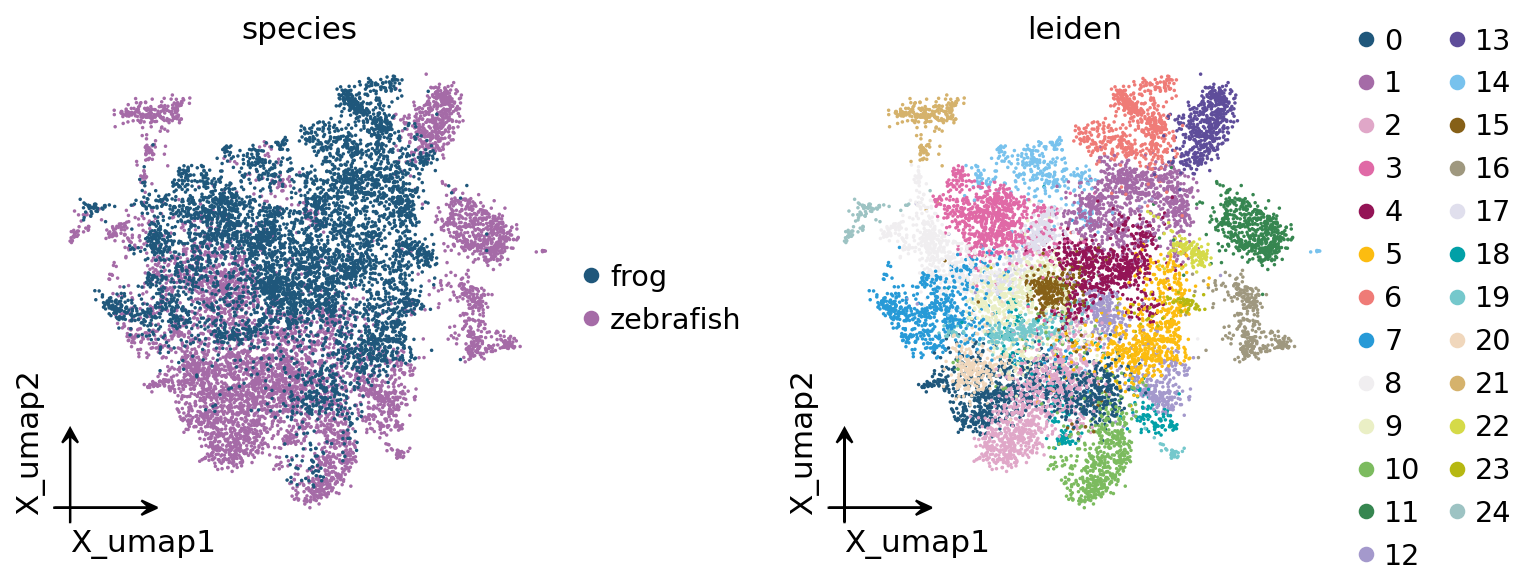

In [6]:
ov.pl.embedding(adata, basis='X_umap', color=['species', 'leiden'],
                frameon='small', wspace=0.4)

Quantify mixing — the fraction of clusters that contain **both** species,
before (raw ortholog PCA) vs after scVI. Good cross-species integration mixes
the shared cell types across species.

In [7]:
ov.pp.neighbors(adata, use_rep='X_pca', n_neighbors=15, key_added='pre')
ov.pp.leiden(adata, resolution=1.0, neighbors_key='pre', key_added='leiden_pre')

def frac_mixed(key):
    t = pd.crosstab(adata.obs[key], adata.obs['species'])
    return ((t['zebrafish'] > 0) & (t['frog'] > 0)).mean()

print(f'clusters with both species  — before: {frac_mixed("leiden_pre"):.2f}'
      f'   after scVI: {frac_mixed("leiden"):.2f}')

INFO:omicverse.pp._neighbors:computing neighbors


🖥️ Using Scanpy CPU to calculate neighbors...

🔍 K-Nearest Neighbors Graph Construction:
   Mode: cpu
   Neighbors: 15
   Method: umap
   Metric: euclidean
   Representation: X_pca
   🔍 Computing neighbor distances...


   🔍 Computing connectivity matrix...
   💡 Using UMAP-style connectivity
   ✓ Graph is fully connected

✅ KNN Graph Construction Completed Successfully!
   ✓ Processed: 12,000 cells with 15 neighbors each
   ✓ Results added to AnnData object:
     • 'pre': Neighbors metadata (adata.uns)
     • 'pre_distances': Distance matrix (adata.obsp)
     • 'pre_connectivities': Connectivity matrix (adata.obsp)

╭─ SUMMARY: neighbors ───────────────────────────────────────────────╮
│  Duration: 1.6314s                                                 │
│  Shape:    12,000 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● UNS    │ ✚ pre                                                  │
│           │ └─ params: {'n_neighbors': 15, 'method': 'umap', 'random_s...│
│                     

    finished (0.60s)
    found 27 clusters and added
    'leiden_pre', the cluster labels (adata.obs, categorical)

╭─ SUMMARY: leiden ──────────────────────────────────────────────────╮
│  Duration: 0.6026s                                                 │
│  Shape:    12,000 x 2,000 (Unchanged)                              │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBS    │ ✚ leiden_pre (category)                                │
│                                                                    │
│  ● UNS    │ ✚ leiden_pre                                           │
│           │ └─ params: {'resolution': 1.0, 'random_state': 0, 'n_itera...│
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯
clusters with both species

## Summary

- `ov.single.get_orthologs` / `map_var_to_orthologs` — homologous-gene transfer
  between any Ensembl species (human, mouse, rat, zebrafish, frog, pig, …).
- `ov.single.cross_species_integrate` — one-call cross-species integration on the
  shared one-to-one orthologs, reusing omicverse's `batch_correction` backends.

**Choosing a backend by evolutionary distance:**

| Species distance | Example | Recommended |
|---|---|---|
| Close | human ↔ mouse | `method='harmony'` (fast, linear) |
| Distant | frog ↔ zebrafish | `method='scVI'` (VAE, this tutorial) |

For homology that is *not* one-to-one (gene duplications, very large distances),
**SAMap** (BLAST homology graph) and **SATURN** (protein language-model
embeddings) are complementary tools that go beyond one-to-one orthologs.